[*********************100%***********************]  121 of 121 completed


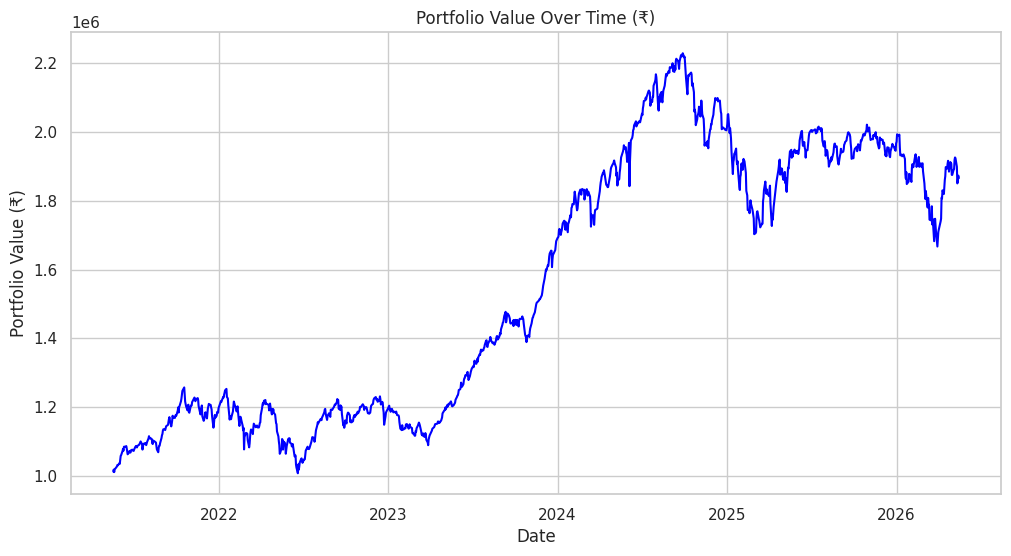

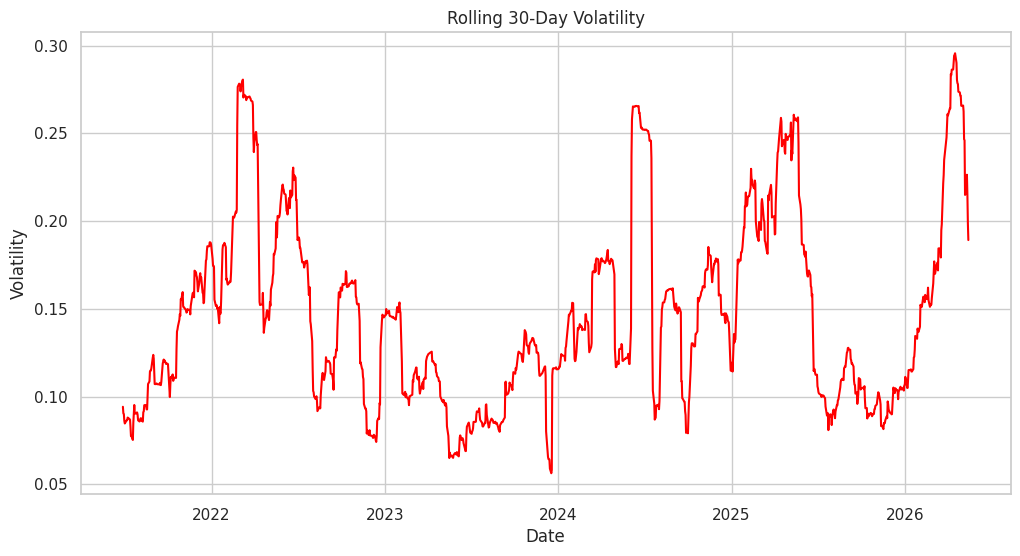

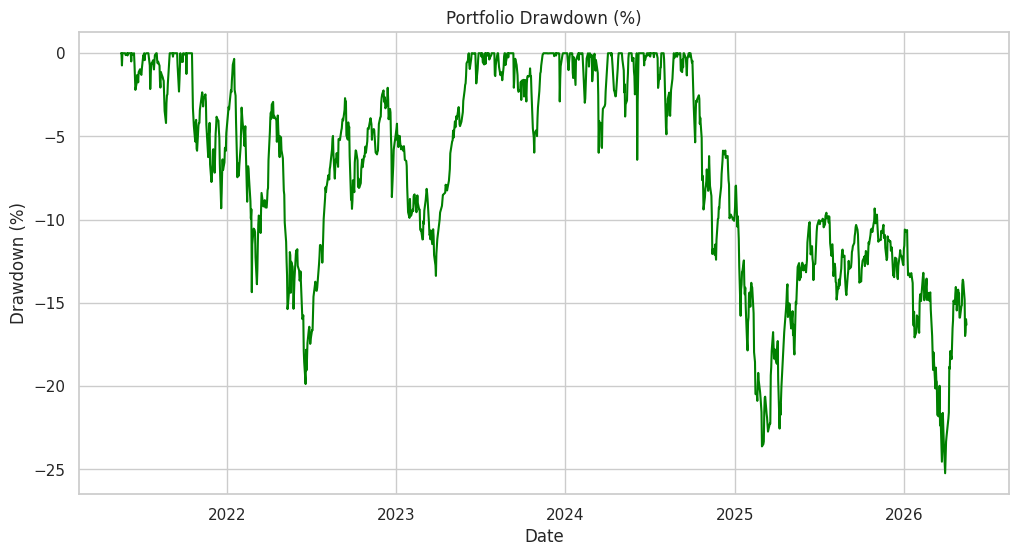

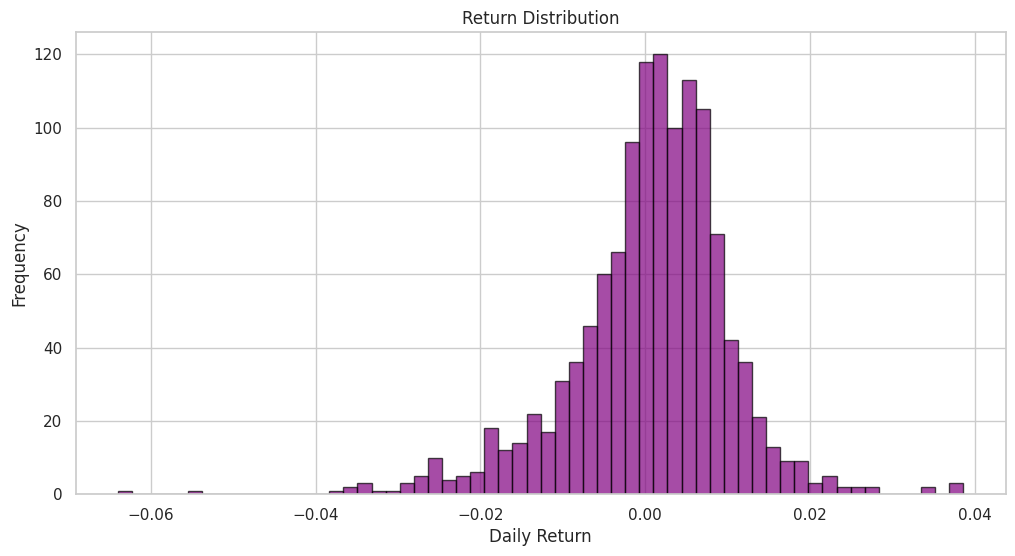

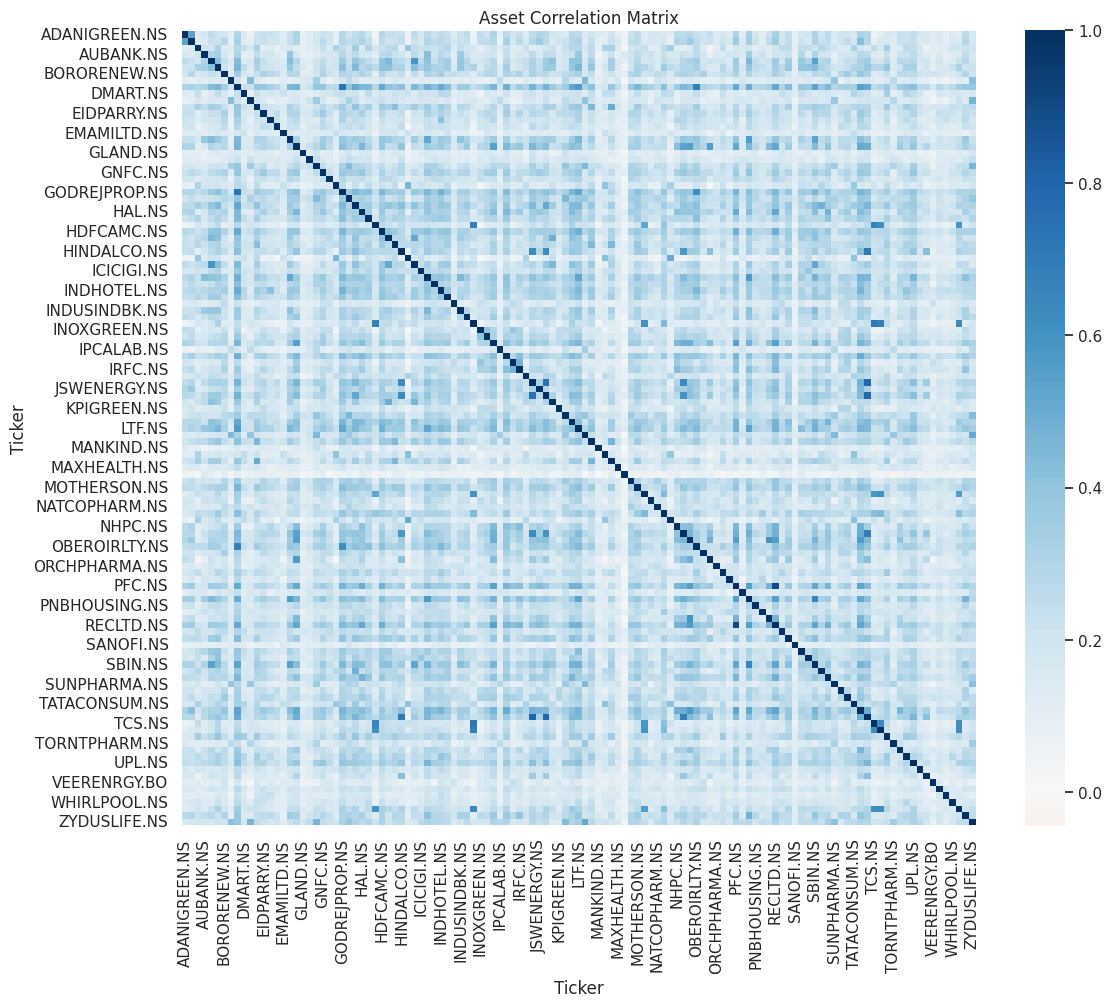

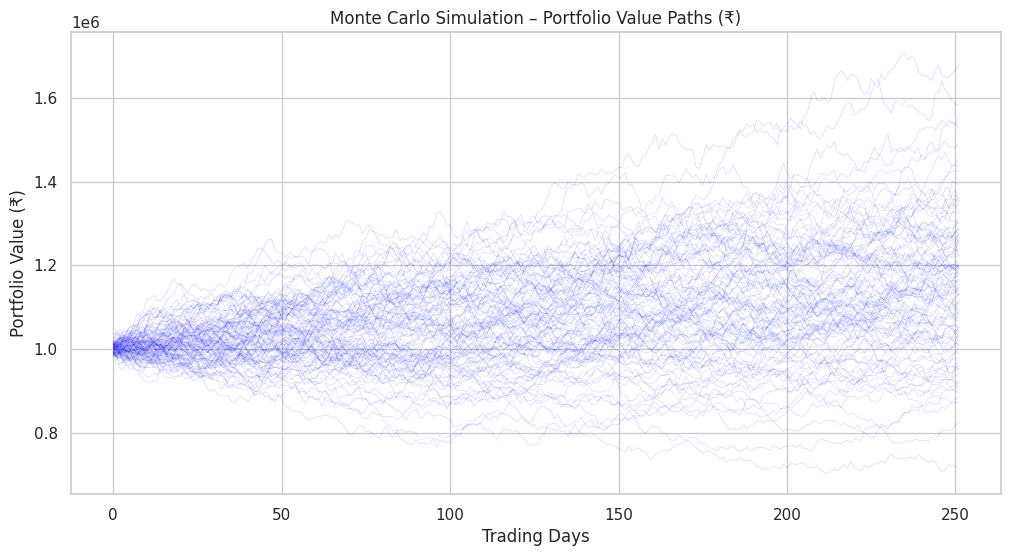

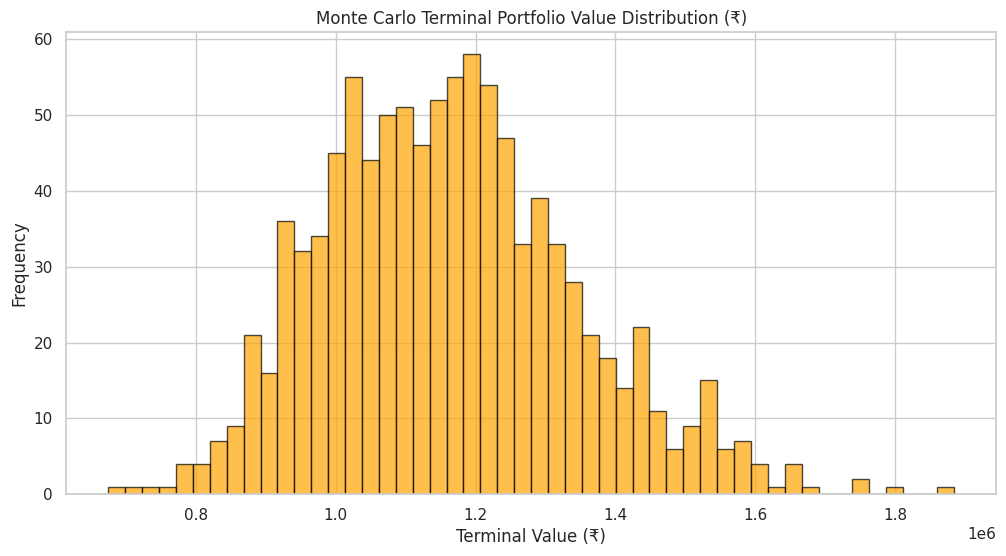

,Metric,Value
0,CAGR (%),13.5466
1,Annual Volatility (%),15.4981
2,Sharpe Ratio,0.4881
3,Max Drawdown (%),-25.2252
4,Max Drawdown (₹),-252252.3900


,Risk Measure,Loss Amount
0,Historical VaR (₹),-17750.05
1,Parametric VaR (₹),-15506.34
2,Monte Carlo VaR (₹),-15504.84
3,Historical ES (₹),-25005.76
4,Monte Carlo ES (₹),-19581.55


(                  Metric        Value
 0               CAGR (%)      13.5466
 1  Annual Volatility (%)      15.4981
 2           Sharpe Ratio       0.4881
 3       Max Drawdown (%)     -25.2252
 4       Max Drawdown (₹) -252252.3900,
           Risk Measure  Loss Amount
 0   Historical VaR (₹)    -17750.05
 1   Parametric VaR (₹)    -15506.34
 2  Monte Carlo VaR (₹)    -15504.84
 3    Historical ES (₹)    -25005.76
 4   Monte Carlo ES (₹)    -19581.55)

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_squared_error
import time
from datetime import timedelta

# ---------------------------------------------------------
# SAFE DOWNLOAD FUNCTION
# ---------------------------------------------------------
def safe_download(symbols, period="5y"):
    df = yf.download(symbols, period=period, auto_adjust=False)

    if isinstance(symbols, list):
        try:
            return df["Adj Close"].ffill().bfill()
        except:
            return df["Close"].ffill().bfill()

    if "Adj Close" in df.columns:
        return df["Adj Close"].ffill().bfill()
    elif "Close" in df.columns:
        return df["Close"].ffill().bfill()

    raise ValueError("No valid price data found")

# ---------------------------------------------------------
# MONTE CARLO SIMULATION
# ---------------------------------------------------------
def monte_carlo_simulation(portfolio_returns, n_simulations=1000, n_days=252):
    mu = portfolio_returns.mean()
    sigma = portfolio_returns.std()

    simulated_log_returns = np.random.normal(
        mu, sigma, size=(n_days, n_simulations)
    )

    simulated_paths = np.exp(simulated_log_returns.cumsum(axis=0))
    return simulated_paths, simulated_log_returns

# ---------------------------------------------------------
# PORTFOLIO ANALYSIS WITH INVESTMENT AMOUNT (Matplotlib plots)
# ---------------------------------------------------------
def portfolio_analysis(
    portfolio_list,
    period="5y",
    risk_free_rate=0.065,
    var_level=0.95,
    invest_amount=1_000_000  # ₹10 lakh default
):

    TRADING_DAYS = 252

    prices = safe_download(portfolio_list, period)
    prices = prices.dropna(axis=1, how='all')
    log_returns = np.log(prices / prices.shift(1)).dropna()

    portfolio_returns = log_returns.mean(axis=1)
    cumulative_returns = (1 + portfolio_returns).cumprod()

    portfolio_value = invest_amount * cumulative_returns

    # -----------------------------
    # METRICS
    # -----------------------------
    n_days = len(portfolio_returns)

    cagr = (cumulative_returns.iloc[-1] ** (TRADING_DAYS / n_days) - 1) * 100
    vol = portfolio_returns.std() * np.sqrt(TRADING_DAYS) * 100
    sharpe = ((portfolio_returns.mean() * TRADING_DAYS) - risk_free_rate) / (vol / 100)

    drawdown = cumulative_returns / cumulative_returns.cummax() - 1
    max_dd_pct = drawdown.min() * 100
    max_dd_amt = invest_amount * drawdown.min()

    # -----------------------------
    # VISUALIZATIONS (Matplotlib)
    # -----------------------------
    # 1. Portfolio value over time
    plt.figure()
    plt.plot(portfolio_value.index, portfolio_value.values, color='blue')
    plt.title("Portfolio Value Over Time (₹)")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value (₹)")
    plt.grid(True)
    plt.show()

    # 2. Rolling 30-day volatility
    rolling_vol = portfolio_returns.rolling(30).std() * np.sqrt(TRADING_DAYS)
    plt.figure()
    plt.plot(rolling_vol.index, rolling_vol.values, color='red')
    plt.title("Rolling 30-Day Volatility")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.grid(True)
    plt.show()

    # 3. Drawdown (%)
    plt.figure()
    plt.plot(drawdown.index, drawdown.values * 100, color='green')
    plt.title("Portfolio Drawdown (%)")
    plt.xlabel("Date")
    plt.ylabel("Drawdown (%)")
    plt.grid(True)
    plt.show()

    # 4. Return distribution (histogram)
    plt.figure()
    plt.hist(portfolio_returns, bins=60, color='purple', edgecolor='black', alpha=0.7)
    plt.title("Return Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # 5. Asset correlation matrix (heatmap)
    corr_matrix = log_returns.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='RdBu', center=0, square=True)
    plt.title("Asset Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # MONTE CARLO
    # -----------------------------
    paths, sim_log_returns = monte_carlo_simulation(portfolio_returns)
    mc_terminal_values = invest_amount * paths[-1]

    # 6. Monte Carlo paths (first 100)
    plt.figure()
    for i in range(min(100, paths.shape[1])):
        plt.plot(invest_amount * paths[:, i], linewidth=0.5, alpha=0.15, color='blue')
    plt.title("Monte Carlo Simulation – Portfolio Value Paths (₹)")
    plt.xlabel("Trading Days")
    plt.ylabel("Portfolio Value (₹)")
    plt.grid(True)
    plt.show()

    # 7. Monte Carlo terminal distribution
    plt.figure()
    plt.hist(mc_terminal_values, bins=50, color='orange', edgecolor='black', alpha=0.7)
    plt.title("Monte Carlo Terminal Portfolio Value Distribution (₹)")
    plt.xlabel("Terminal Value (₹)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # -----------------------------
    # VALUE AT RISK (VaR)
    # -----------------------------
    alpha = 1 - var_level

    # % VaR
    hist_var_pct = np.percentile(portfolio_returns, alpha * 100)
    para_var_pct = portfolio_returns.mean() + portfolio_returns.std() * norm.ppf(alpha)
    mc_var_pct = np.percentile(sim_log_returns.flatten(), alpha * 100)

    # ₹ VaR
    hist_var_amt = invest_amount * hist_var_pct
    para_var_amt = invest_amount * para_var_pct
    mc_var_amt = invest_amount * mc_var_pct

    # Expected Shortfall
    hist_es_pct = portfolio_returns[portfolio_returns <= hist_var_pct].mean()
    mc_es_pct = sim_log_returns.flatten()[sim_log_returns.flatten() <= mc_var_pct].mean()

    hist_es_amt = invest_amount * hist_es_pct
    mc_es_amt = invest_amount * mc_es_pct

    # -----------------------------
    # SUMMARY TABLES
    # -----------------------------
    performance_summary = pd.DataFrame({
        "Metric": [
            "CAGR (%)",
            "Annual Volatility (%)",
            "Sharpe Ratio",
            "Max Drawdown (%)",
            "Max Drawdown (₹)"
        ],
        "Value": [
            round(cagr, 4),
            round(vol, 4),
            round(sharpe, 4),
            round(max_dd_pct, 4),
            round(max_dd_amt, 2)
        ]
    })

    var_summary = pd.DataFrame({
        "Risk Measure": [
            "Historical VaR (₹)",
            "Parametric VaR (₹)",
            "Monte Carlo VaR (₹)",
            "Historical ES (₹)",
            "Monte Carlo ES (₹)"
        ],
        "Loss Amount": [
            round(hist_var_amt, 2),
            round(para_var_amt, 2),
            round(mc_var_amt, 2),
            round(hist_es_amt, 2),
            round(mc_es_amt, 2)
        ]
    })

    display(performance_summary)
    display(var_summary)

    return performance_summary, var_summary

# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------
portfolio_list = [
    "IDFCFIRSTB.NS", "PNB.NS", "AUBANK.NS", "HDFCBANK.NS", "ICICIBANK.NS",
    "BAJAJFINSV.NS", "CIPLA.NS", "DRREDDY.NS", "IPCALAB.NS", "LUPIN.NS",
    "ZYDUSLIFE.NS", "SBICARD.NS", "ASIANPAINT.NS", "HINDUNILVR.NS", "TCS.NS",
    "INFY.NS", "LT.NS", "MARUTI.NS", "SUNPHARMA.NS", "WIPRO.NS",
    "ADANIGREEN.NS", "ADANIPOWER.NS", "DLF.NS", "DMART.NS", "EIDPARRY.NS",
    "EICHERMOT.NS", "EIHOTEL.NS", "ELGIEQUIP.NS", "EMAMILTD.NS", "FEDERALBNK.NS",
    "GAIL.NS", "GLAND.NS", "GLAXO.NS", "GLENMARK.NS", "GNFC.NS",
    "GODREJAGRO.NS", "GODREJCP.NS", "GODREJPROP.NS", "GRANULES.NS", "GRASIM.NS",
    "HAL.NS", "HAVELLS.NS", "HCLTECH.NS", "HDFCAMC.NS",
    "HEROMOTOCO.NS", "HINDALCO.NS", "ICICIGI.NS",
    "IEX.NS", "INDHOTEL.NS", "INDIGO.NS", "INDOWIND.NS", "INDUSTOWER.NS",
    "INDUSINDBK.NS", "INOXGREEN.NS", "INOXWIND.NS",
    "IOC.NS", "IRCTC.NS", "IRFC.NS", "ITC.NS",
    "JINDALSTEL.NS", "JSWENERGY.NS", "JSWSTEEL.NS", "KOTAKBANK.NS", "KPIGREEN.NS",
    "LAURUSLABS.NS", "LTF.NS", "M&M.NS",
    "MANKIND.NS", "MARICO.NS", "MAXHEALTH.NS",
    "MOREPENLAB.NS", "MOTHERSON.NS", "MPHASIS.NS", "NATCOPHARM.NS", "NAUKRI.NS",
    "NESTLEIND.NS", "NHPC.NS", "NMDC.NS", "NTPC.NS",
    "OBEROIRLTY.NS", "OLECTRA.NS", "ONGC.NS", "ORCHPHARMA.NS",
    "PAGEIND.NS", "PAYTM.NS", "PFC.NS", "PFIZER.NS",
    "PNBHOUSING.NS", "POLICYBZR.NS", "POWERGRID.NS", "RECLTD.NS", "RELAXO.NS",
    "RELIANCE.NS", "SANOFI.NS", "SBIN.NS", "SBILIFE.NS",
    "SHREECEM.NS", "SIEMENS.NS",
    "SUZLON.NS", "SWSOLAR.NS", "TATACONSUM.NS", "TATAPOWER.NS", "TATASTEEL.NS",
    "TECHM.NS", "TITAN.NS", "TORNTPHARM.NS", "TORNTPOWER.NS",
    "TRENT.NS", "UPL.NS", "VBL.NS", "VEDL.NS",
    "VGUARD.NS", "WESTLIFE.NS", "WHIRLPOOL.NS", "YESBANK.NS",
    "IREDA.NS", "MINDSPACE.NS", "MUTHOOTCAP.NS", "BORORENEW.NS",
    "VEERENRGY.BO", "AXISBANK.NS",
]

portfolio_analysis(
    portfolio_list=portfolio_list,
    period="5y",
    risk_free_rate=0.0635,
    var_level=0.95,
    invest_amount=1_000_000  # ₹10 lakh
)